# Metrics report
___

This report calculates a couple of key SaaS metrics that help assess the recurring revenue health of the business:
- ARR (Annual Recurring Revenue) – Predictable yearly income from active licenses.
- MRR (Monthly Recurring Revenue) – Predictable monthly income from the same customer base.
- ARPU (Average Revenue Per User) – Average monthly revenue generated per active license.

In [1]:
from working_with_db import *
from make_chart import *

conn = connect_to_local_postgresql(db_name='postgres', user='jet', password='brains')

metrics_df = execute_query_to_dataframe(conn, read_sql_file_to_string('metrics/mrr_and_arr.sql'))

mrr_df = metrics_df[metrics_df['metric_name'] == 'MRR']
arr_df = metrics_df[metrics_df['metric_name'] == 'ARR']
arpu_df = metrics_df[metrics_df['metric_name'] == 'ARPU']

Connection to DB successful


# Key points

1. **Sales segmentation**
    - Excluding customers who have made exactly one purchase and have the "new customer" status.

2. **Licenses are classified based on price per license:**
   - If the cost < $35, it's treated as a monthly subscription.
   - Otherwise, it's treated as annual.

   The constant $35 was chosen based on the [jetbrains.com/store](https://www.jetbrains.com/store) page.

3. **Payment Splitting Logic:**
   - Each payment is allocated proportionally across its subscription duration.
   - The first month receives a prorated share based on how late in the month the payment was made.
   - The following months receive evenly distributed revenue (rest_payment).
   - The final month may receive a correction value to handle rounding differences.

#### Data context
The data covers the period from January 2018 to December 2020.
<br>The charts continue into 2021, but new data ends in 2020, so later values are based on previously sold licenses.

All charts show a sharp decline starting in January 2021.
<br>However, this:
- Does not reflect a real business downturn.
- It is not caused by user churn or loss in sales.

Reason: only transactions made up to the end of 2020 are included in the dataset. No new subscriptions are recorded after that point, while existing ones gradually expire over time.

# MRR (Monthly Recurring Revenue)
---

MRR = Σ (lisenses_price / lisense_length_in_months)

#### Observations
Growth from early 2018 to late 2020.
<br>MRR shows a steady, linear increase throughout the period.
<br>This indicates consistent growth in new licenses.

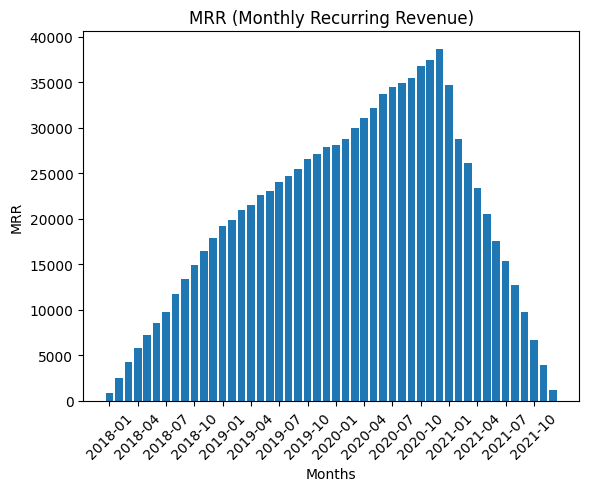

In [3]:
make_chart(dataframe=mrr_df,
           x_column='dt', y_column='value',
           chart_type=ChartType.BAR,
           title='MRR (Monthly Recurring Revenue)',
           xlabel='Months', ylabel='MRR')


# ARR (Annual Recurring Revenue)
___
 ARR = MRR * 12
#### Observations
The ARR chart confirms the long-term sustainability of revenues shown in the MRR chart.

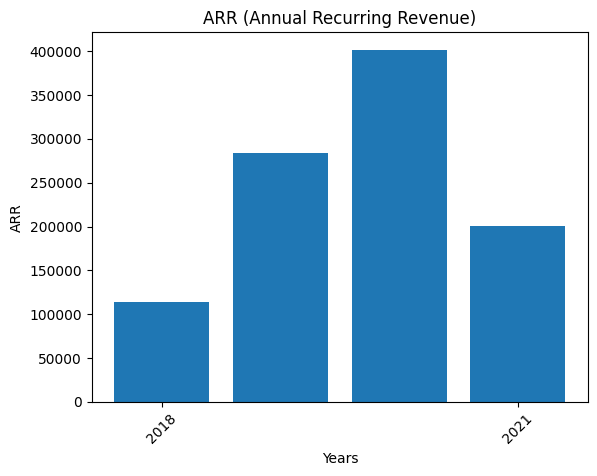

In [4]:
make_chart(dataframe=arr_df,
           x_column='dt', y_column='value',
           chart_type=ChartType.BAR,
           title='ARR (Annual Recurring Revenue)',
           xlabel='Years', ylabel='ARR')

# ARPU (Average Revenue Per User)
---
ARPU = MRR / number_of_regular_users.
Regular users have 2 and more payments.

#### Observations
1. ARPU growth from early 2018 to mid-2019. Strong upward trend indicates improved retention or an increase in average order value regular users.
2. Plateau and gradual decline in 2020–2021.
After peaking in 2019, ARPU stabilizes and then slowly declines.

#### Possible reasons:

- Growth in lower-priced subscriptions.
- Acquisition of new customers with smaller average payments.
- Reduced activity from earlier high-paying users.

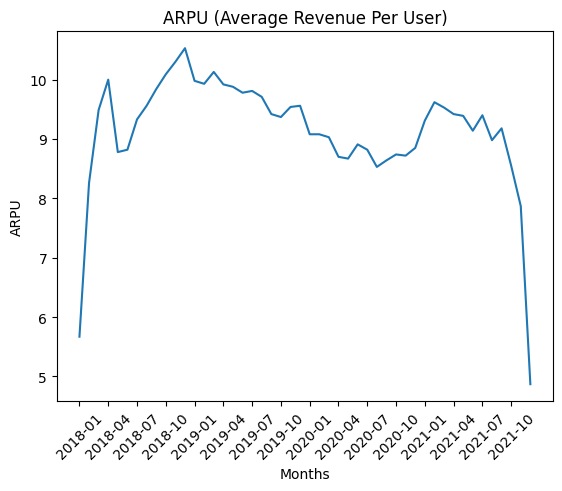

In [5]:
make_chart(dataframe=arpu_df,
           x_column='dt', y_column='value',
           chart_type=ChartType.LINE,
           title='ARPU (Average Revenue Per User)',
           xlabel='Months', ylabel='ARPU')